# Ocean Kinematics — GLORYS vs DUACS at 0.25°

Tour of the kinematic transformations in `xr_toolz.ocn`, applied side-by-side to two real Gulf Stream products:

- **GLORYS12** — 1/12° reanalysis. Carries `(zos, uo, vo)` directly: prognostic surface velocities from the OGCM.
- **DUACS L4** — 1/8° altimeter SSH only (`adt`). We derive $(u_g, v_g)$ via `geostrophic_velocities` — the standard altimetry-only diagnostic flow.

Both products are first regridded to a shared **0.25° target grid** so every transformation is comparable cell-for-cell. Each section below introduces one diagnostic with the same five-part structure: (1) plain-English intuition; (2) formal definition; (3) continuous mathematical formulation; (4) what we actually compute numerically; (5) interpretation and use cases. The two-panel figures highlight where DUACS — being purely geostrophic by construction — agrees with GLORYS, and where GLORYS's prognostic flow carries ageostrophic structure that altimetry cannot see.

Stratification, density, and along-track diagnostics are deferred to companion notebooks in this PR.

## Numerical methods

Every spatial derivative in `xr_toolz.ocn` delegates to `xr_toolz.calc.partial`, which is a thin xarray wrapper around `finitediffx`. On a lat/lon grid the underlying scheme is a **second-order central finite difference** (default `accuracy=1`, `method="central"`) on the **spherical metric**:

$$
    \frac{\partial F}{\partial x} = \frac{1}{R \cos\varphi}\,\frac{\partial F}{\partial \lambda},
    \qquad
    \frac{\partial F}{\partial y} = \frac{1}{R}\,\frac{\partial F}{\partial \varphi},
$$

with $R$ the Earth radius, $\varphi$ latitude, $\lambda$ longitude. Discretely:

$$
    \left.\frac{\partial F}{\partial x}\right|_{i,j}
        \approx \frac{F_{i,j+1} - F_{i,j-1}}{2\,R\cos\varphi_i\,\Delta\lambda},
    \qquad
    \left.\frac{\partial F}{\partial y}\right|_{i,j}
        \approx \frac{F_{i+1,j} - F_{i-1,j}}{2\,R\,\Delta\varphi}.
$$

Edge cells fall back to one-sided differences. Higher-order accuracy is available as a kwarg but the default is sufficient for the structure-level comparisons below. Vector / tensor diagnostics (vorticity, strain, divergence) are then **algebraic combinations of these primitive partials** — no separate discretisation choices to worry about per quantity.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

# Silence third-party deprecation noise that clutters the rendered notebook.
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from xr_toolz import Augment, Graph, Input, Sequential
from xr_toolz.geo.operators import RemoveMean
from xr_toolz.interpolate import regrid_like
from xr_toolz.ocn import (
    coriolis_normalized,
    coriolis_parameter,
    validate_ssh,
    validate_velocity,
)
from xr_toolz.ocn.operators import (
    AbsoluteVorticity,
    AgeostrophicVelocities,
    CurvatureVorticity,
    Divergence,
    EddyKineticEnergy,
    Enstrophy,
    Frontogenesis,
    GeostrophicVelocities,
    HorizontalVelocityMagnitude,
    KineticEnergy,
    OkuboWeiss,
    RelativeVorticity,
    ShearStrain,
    ShearVorticity,
    StrainMagnitude,
    Streamfunction,
    TensorStrain,
    VelocityMagnitude,
)

GLORYS_CACHE = Path("../../.cache/glorys12_3d_gulfstream_2023-06.nc")
DUACS_CACHE = Path("../../.cache/duacs_gulfstream_2023-06.nc")

## 1 — Load and regrid both products to 0.25°

`regrid_like` is the single line that puts GLORYS and DUACS on the same grid. We grab GLORYS's surface (top depth level) and the matching 5-day DUACS window, then interpolate both onto a 0.25° target lat/lon. After regridding, GLORYS keeps `(zos, uo, vo)`; DUACS gains `(u, v)` derived from `adt` via `geostrophic_velocities`.

In [2]:
glorys_raw = (
    xr.open_dataset(GLORYS_CACHE)
    .rename({"latitude": "lat", "longitude": "lon"})
    .isel(depth=0)
)
glorys_raw = glorys_raw.assign_coords(
    lat=("lat", np.linspace(float(glorys_raw.lat[0]), float(glorys_raw.lat[-1]), glorys_raw.sizes["lat"])),
    lon=("lon", np.linspace(float(glorys_raw.lon[0]), float(glorys_raw.lon[-1]), glorys_raw.sizes["lon"])),
)
duacs_raw = (
    xr.open_dataset(DUACS_CACHE)
    .rename({"latitude": "lat", "longitude": "lon"})
    .isel(time=slice(0, 5))
)

target = xr.Dataset(
    coords={
        "lat": ("lat", np.arange(30.0, 45.01, 0.25), {"units": "degrees_north"}),
        "lon": ("lon", np.arange(-70.0, -49.99, 0.25), {"units": "degrees_east"}),
    }
)

glorys = (
    regrid_like(glorys_raw, target)
    .rename({"zos": "ssh", "uo": "u", "vo": "v"})[["ssh", "u", "v"]]
)
duacs = regrid_like(duacs_raw, target).rename({"adt": "ssh"})

# Derive geostrophic (u, v) for DUACS — its only kinematic state besides SSH.
duacs = duacs.merge(GeostrophicVelocities(variable="ssh")(duacs), compat="no_conflicts")

# Validators raise on missing / mis-shaped fields; pass-throughs on success.
validate_ssh(glorys, variable="ssh")
validate_ssh(duacs, variable="ssh")
validate_velocity(glorys, u="u", v="v")
validate_velocity(duacs, u="u", v="v")

print("GLORYS @ 0.25°:", dict(glorys.sizes), list(glorys.data_vars))
print("DUACS  @ 0.25°:", dict(duacs.sizes), list(duacs.data_vars))

GLORYS @ 0.25°: {'time': 5, 'lat': 61, 'lon': 81} ['ssh', 'u', 'v']
DUACS  @ 0.25°: {'time': 5, 'lat': 61, 'lon': 81} ['ssh', 'u', 'v']


Throughout the rest of the notebook we work on the time-mean snapshot for clarity (5-day mean, 2023-06-01 → 06-05). Eddy-kinetic-energy below is the one diagnostic that uses the full time series.

In [3]:
glorys_t = glorys.mean(dim="time")
duacs_t = duacs.mean(dim="time")


def two_panel(da_g, da_d, title, *, vlim=None, cmap="RdBu_r", center_zero=True):
    """Standard side-by-side comparison figure with constrained layout."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True, constrained_layout=True)
    if vlim is None:
        v = float(np.nanmax(np.abs([np.nanmax(np.abs(da_g)), np.nanmax(np.abs(da_d))])))
        vlim = (-v, v) if center_zero else (0, v)
    for ax, da, label in zip(axes, [da_g, da_d], ["GLORYS", "DUACS (Geostrophic)"], strict=True):
        im = ax.pcolormesh(da["lon"], da["lat"], da.values, vmin=vlim[0], vmax=vlim[1], cmap=cmap)
        ax.set_title(f"{label} — {title}", fontsize=10)
        ax.set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    plt.show()

## 2 — Coriolis: the geometric backbone

**ELI5.** The Earth spins. Anything moving over a long-enough distance feels a sideways nudge — left in the Southern Hemisphere, right in the Northern. The Coriolis parameter measures how strong that nudge is at each latitude.

**What it is.** $f$ is the local vertical component of the planet's rotation rate. It vanishes at the equator (rotation axis is horizontal there) and reaches its maximum at the poles. Almost every large-scale balance in the ocean — geostrophy, vorticity, potential vorticity — uses $f$ as its scaling.

**Continuous formulation.**

$$
    f(\varphi) = 2\,\Omega\,\sin\varphi,
$$

where $\Omega = 7.2921 \times 10^{-5}$ rad/s is Earth's angular velocity and $\varphi$ is latitude. A second helper, the **Coriolis-normalized** field, divides any quantity by the mid-domain $f_0$:

$$
    \tilde{F}(x,y) = \frac{F(x,y)}{f_0}, \qquad f_0 = f(\varphi_0).
$$

Applied to relative vorticity $\zeta$, this returns the local **Rossby number** $\zeta/f_0$ — a dimensionless measure of the flow's nonlinearity.

**Discretisation.** Pure analytic evaluation — no derivatives. `coriolis_parameter(lat_da)` is a vectorised `2 Ω sin(lat·π/180)`. `coriolis_normalized` looks up $f_0$ at the centre latitude of the dataset and broadcasts the division.

**Interpretation.** $f$ ranges from $\sim 7 \times 10^{-5}$ at 30°N to $\sim 1 \times 10^{-4}$ at 45°N over our box (left panel below). The right panel shows $\zeta / f_0$ for the GLORYS time-mean: values of order ±0.3 mark the Gulf Stream front where the flow is most strongly nonlinear (Rossby number is no longer ≪ 1). When $|\zeta/f_0|$ approaches 1, geostrophic balance starts to break down and ageostrophic terms become important — the link to § 3.

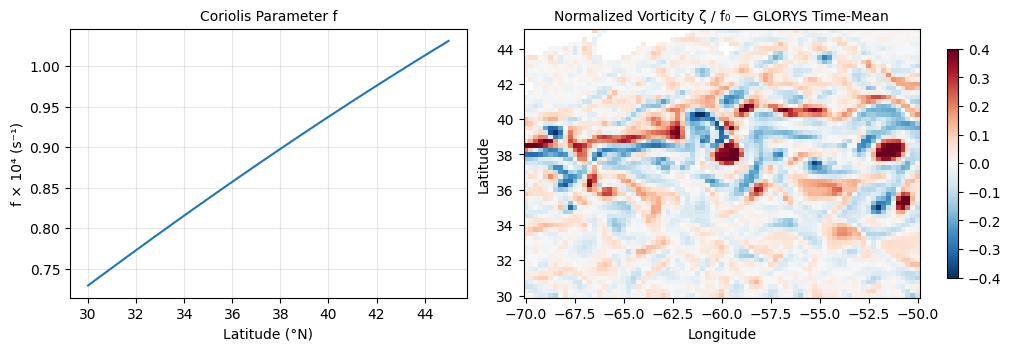

In [4]:
f = coriolis_parameter(glorys["lat"])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(glorys["lat"], f.values * 1e4)
axes[0].set_xlabel("Latitude (°N)")
axes[0].set_ylabel("f × 10⁴ (s⁻¹)")
axes[0].set_title("Coriolis Parameter f", fontsize=10)
axes[0].grid(alpha=0.3)

# Normalised relative vorticity = ζ / f₀ (a Rossby-number proxy).
ds_with_vort = glorys_t.merge(RelativeVorticity()(glorys_t), compat="no_conflicts")
rossby = coriolis_normalized(ds_with_vort, variable="vort_r")
im = axes[1].pcolormesh(
    rossby["lon"], rossby["lat"], rossby["vort_r"].values,
    vmin=-0.4, vmax=0.4, cmap="RdBu_r",
)
axes[1].set_title("Normalized Vorticity ζ / f₀ — GLORYS Time-Mean", fontsize=10)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(im, ax=axes[1], shrink=0.85, pad=0.02)
plt.show()

## 3 — From SSH to flow: geostrophic, ageostrophic, streamfunction

### 3a. Geostrophic velocities

**ELI5.** If you tilt a basin of water on a spinning planet, gravity wants the water to flow downhill — but the rotation deflects it sideways. The result is that the water flows *along* the slope, not across it. Geostrophic velocity is what falls out of that bargain.

**What it is.** The horizontal velocity in steady, frictionless, rotation-dominated flow where the pressure-gradient force exactly balances the Coriolis force. It is the leading-order approximation to the large-scale, slow ocean circulation away from boundaries — and it is the *only* velocity an altimeter can see, because altimeters measure SSH and SSH alone determines $u_g$, $v_g$.

**Continuous formulation.**

$$
    u_g = -\frac{g}{f}\,\frac{\partial \eta}{\partial y},
    \qquad
    v_g = \frac{g}{f}\,\frac{\partial \eta}{\partial x},
$$

where $\eta$ is sea-surface height. Equivalent statement: the geostrophic flow is rotated 90° from the SSH gradient, with magnitude proportional to the slope.

**Discretisation.** Both partials use the spherical-metric central FD from the preamble. The output Dataset names its variables `u`, `v` — overwriting any existing velocities under those names by default. Pass `variable="ssh"` (the default) to point at the height field name in your input.

**Interpretation.** For DUACS this *is* the flow — there is no other estimate. For GLORYS this is the geostrophic *component* of the prognostic velocities, which lets us compute the residual in § 3b. Comparing the geostrophic-speed panels shows that both products agree on the bulk Gulf Stream jet structure; the disagreement is in the smaller scales.

### 3b. Ageostrophic velocities

**ELI5.** The bits of the flow that don't obey the geostrophic shortcut — wind drag, inertial wobbles, sub-mesoscale fronts.

**What it is.** The residual $(u - u_g, v - v_g)$. For altimetry this is identically zero by construction (DUACS's $u, v$ *are* $u_g, v_g$). For a model with prognostic velocities like GLORYS, it captures everything outside the geostrophic balance — Ekman drift, inertial oscillations, ageostrophic fronts, and sub-mesoscale structure.

**Continuous formulation.**

$$
    u_a = u - u_g, \qquad v_a = v - v_g.
$$

**Discretisation.** Two central-FD calls (one per geostrophic component) followed by elementwise subtraction. Output variables are named `u_a`, `v_a`.

**Interpretation.** A non-zero ageostrophic field tells you the geostrophic approximation is leaking — typical magnitudes are 1-10 cm/s in the Gulf Stream region, against a geostrophic flow of 0.5-1 m/s. The DUACS panel below should be at machine precision (good sanity check on the implementation); the GLORYS panel reveals where the prognostic ocean is doing things altimetry cannot resolve.

### 3c. Streamfunction

**ELI5.** Draw contour lines of $\psi$ — water flows along the contours, faster where they're packed tightly together. Same principle as a topographic map for streamlines.

**What it is.** A horizontal-only scalar field whose gradient is the geostrophic flow rotated 90°. By definition $u_g = -\partial \psi / \partial y$, $v_g = \partial \psi / \partial x$, so geostrophic streamlines coincide with isolines of $\psi$.

**Continuous formulation.**

$$
    \psi(x,y) = \frac{g}{f_0}\,\eta(x,y).
$$

Note this uses a **single** $f_0$ (not the latitude-varying $f$), so $\psi$ is exactly proportional to SSH on $f$-plane assumptions. A more general expression replaces $g/f_0$ with $g/f(\varphi)$ at the cost of strict differentiability.

**Discretisation.** No derivatives — pure scalar multiplication after looking up $f_0$ at the centre latitude.

**Interpretation.** Useful for visualising the flow without arrows: closed contours indicate gyres / eddies; tightly-packed contours show jets; sign of $\psi$ encodes the rotation direction. The two panels below differ only in their underlying SSH fields — DUACS's adt has had different processing than GLORYS's zos, hence the slight offset/scale differences.

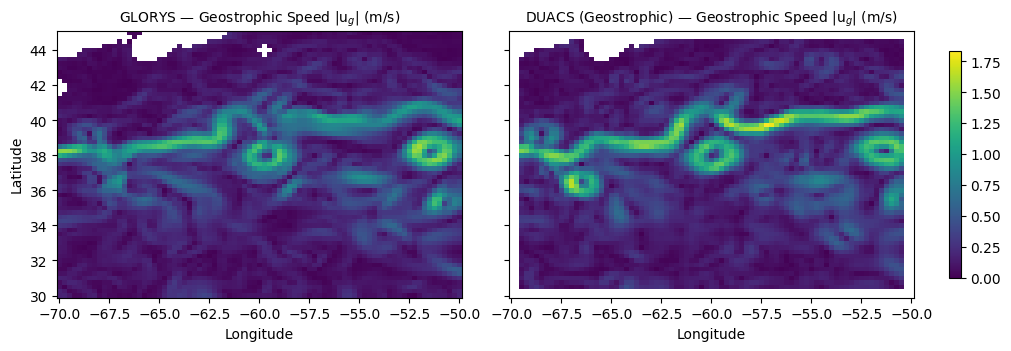

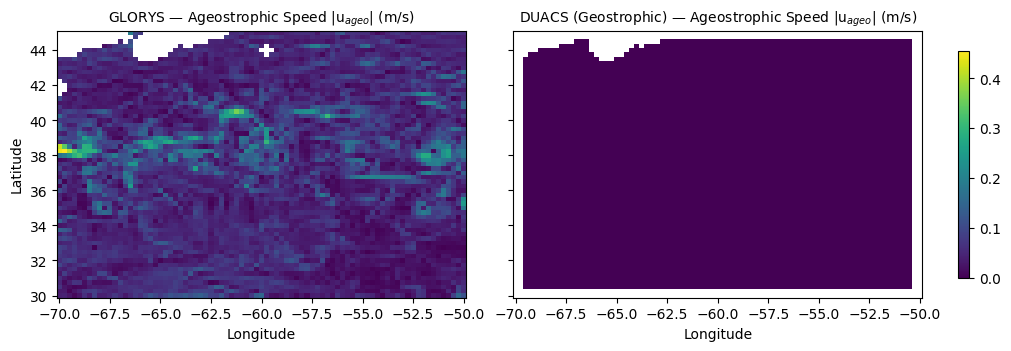

In [5]:
geo_op = GeostrophicVelocities(variable="ssh")
ag_op = AgeostrophicVelocities(variable="ssh", u="u", v="v")

geo_g = geo_op(glorys_t)
geo_d = geo_op(duacs_t)
ag_g = ag_op(glorys_t)
ag_d = ag_op(duacs_t)

geo_speed = HorizontalVelocityMagnitude(u="u", v="v")
ag_speed = HorizontalVelocityMagnitude(u="u_a", v="v_a")

two_panel(
    geo_speed(geo_g)["speed"],
    geo_speed(geo_d)["speed"],
    "Geostrophic Speed |u$_g$| (m/s)",
    cmap="viridis",
    center_zero=False,
)
two_panel(
    ag_speed(ag_g)["speed"],
    ag_speed(ag_d)["speed"],
    "Ageostrophic Speed |u$_{ageo}$| (m/s)",
    cmap="viridis",
    center_zero=False,
)

`streamfunction` ψ = (g/f₀) η is a horizontal-only diagnostic — flow lines coincide with isolines of ψ. Because both products use the same `g/f₀`, the visible difference is purely the difference in their SSH fields.

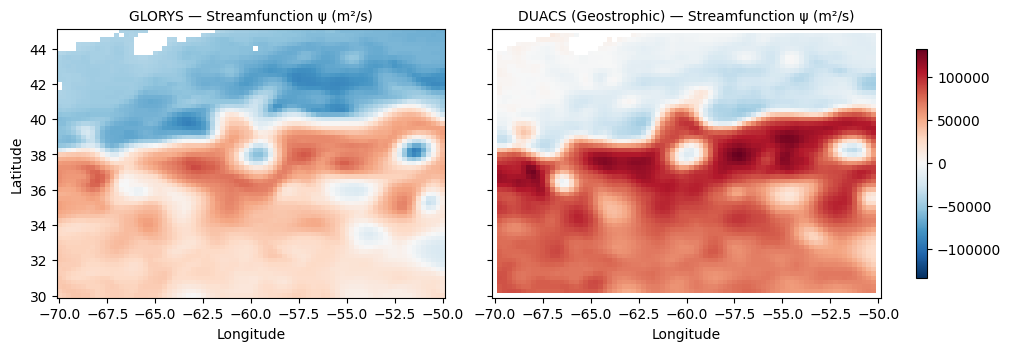

In [6]:
sf_op = Streamfunction(variable="ssh")
sf_g = sf_op(glorys_t)
sf_d = sf_op(duacs_t)
two_panel(sf_g["psi"], sf_d["psi"], "Streamfunction ψ (m²/s)")

## 4 — Velocity diagnostics

### 4a. Velocity magnitude

**ELI5.** How fast is the water moving — full stop, ignoring direction?

**What it is.** The Euclidean norm of the velocity vector. The 2-D variant ignores any vertical component; the 3-D variant `VelocityMagnitude(u, v, w)` includes it. `HorizontalVelocityMagnitude` is the dedicated 2-D operator we used earlier on the geostrophic / ageostrophic outputs.

**Continuous formulation.**

$$
    |\mathbf{u}| = \sqrt{u^2 + v^2 + w^2}, \qquad |\mathbf{u}_h| = \sqrt{u^2 + v^2}.
$$

**Discretisation.** Pointwise — no derivatives. The op simply elementwise-evaluates the formula and returns a Dataset with a single `speed` variable.

**Interpretation.** The fastest water in the Gulf Stream reaches 1+ m/s; both products show this clearly. Speed is what you reach for when you need a single intuitive map of "where the action is" without getting into vector plots.

### 4b. Kinetic energy

**ELI5.** Half of velocity squared. The thing that goes up when the flow speeds up, and that conserves (per unit mass) for an inviscid incompressible fluid.

**What it is.** Specific kinetic energy — the per-unit-mass kinetic energy of the horizontal flow. The full ocean energy budget tracks this against potential energy, dissipation, and forcing.

**Continuous formulation.**

$$
    \mathrm{KE} = \frac{1}{2}\,(u^2 + v^2),
$$

in m²/s² (energy per kg).

**Discretisation.** Pointwise squared sum. No derivatives.

**Interpretation.** KE is more dynamic-range-friendly than speed for visualisation — it accentuates the jet core relative to the surrounding eddy field. Compare against EKE below to separate "where the flow is fast on average" from "where the flow varies a lot in time".

### 4c. Eddy kinetic energy

**ELI5.** Take the time-mean velocity, subtract it from every snapshot, and compute kinetic energy of what's left over. That tells you how unsteady the flow is — i.e. how much of the energy is in eddies and waves rather than the steady currents.

**What it is.** The kinetic energy of the velocity *anomalies* — the Reynolds-decomposition fluctuating component. Standard diagnostic for eddy-rich regions (Gulf Stream, Kuroshio, ACC) and a key benchmark for ocean models, since the eddy field is typically what reanalyses and altimetry can resolve while wind forcing alone cannot reproduce.

**Continuous formulation.** With $\overline{(\cdot)}$ a temporal mean and $u' = u - \overline{u}$:

$$
    \mathrm{EKE} = \frac{1}{2}\,\overline{u'^2 + v'^2}.
$$

**Discretisation.** Two steps:

1. `RemoveMean(("time",))` subtracts the temporal mean from each velocity component (Reynolds decomposition).
2. `EddyKineticEnergy(u_anom="u_anom", v_anom="v_anom")` evaluates $\frac{1}{2}(u'^2 + v'^2)$ pointwise; we then average over time to get the climatological EKE map.

**Interpretation.** The EKE distribution highlights the meandering Gulf Stream and the rings shed off it. EKE is generally larger in GLORYS than in DUACS at small scales because GLORYS resolves transients that the L4 altimetry product smooths over. EKE is also a cornerstone metric for evaluating ocean reanalyses against observation — too low EKE means the model is over-damped; too high means the eddy parameterisations are leaking energy.

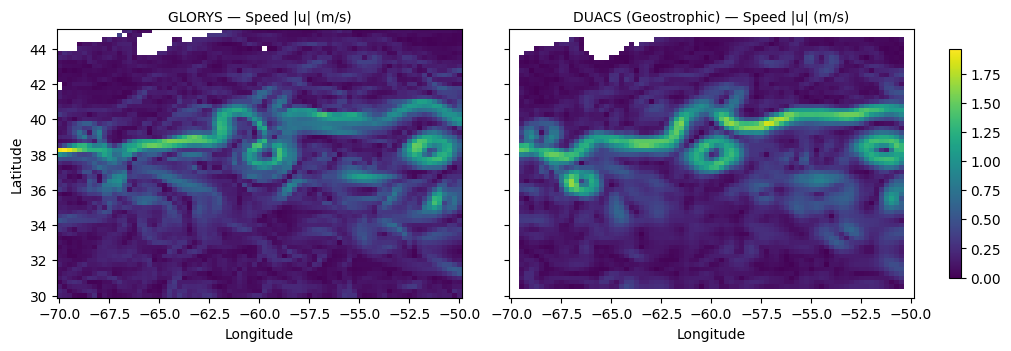

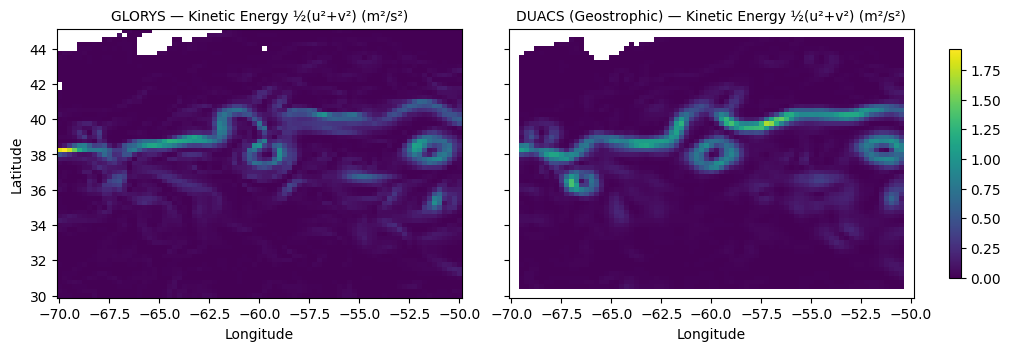

In [7]:
vmag_op = VelocityMagnitude(u="u", v="v")
ke_op = KineticEnergy(u="u", v="v")

two_panel(
    vmag_op(glorys_t)["speed"], vmag_op(duacs_t)["speed"],
    "Speed |u| (m/s)", cmap="viridis", center_zero=False,
)
two_panel(
    ke_op(glorys_t)["ke"], ke_op(duacs_t)["ke"],
    "Kinetic Energy ½(u²+v²) (m²/s²)", cmap="viridis", center_zero=False,
)

Implementation:

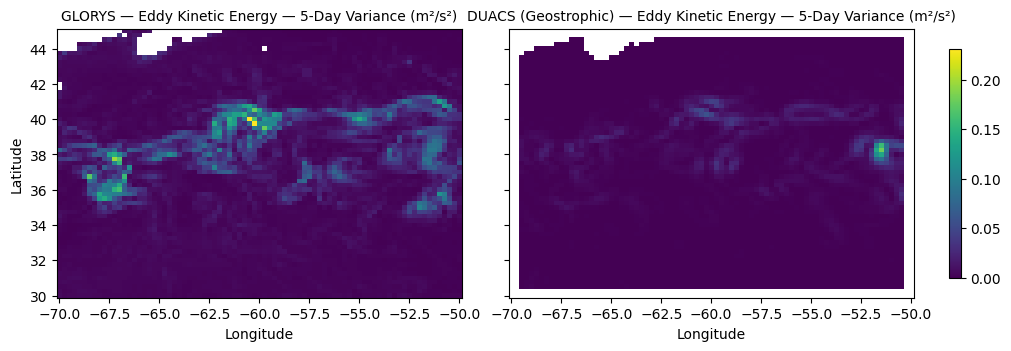

In [8]:
remove_time_mean = RemoveMean(("time",))
eke_op = EddyKineticEnergy(u_anom="u_anom", v_anom="v_anom")


def eke(ds):
    """Build (u_anom, v_anom) via RemoveMean, then call EddyKineticEnergy."""
    anoms = remove_time_mean(ds[["u", "v"]]).rename({"u": "u_anom", "v": "v_anom"})
    return eke_op(anoms)["eke"].mean(dim="time")


two_panel(
    eke(glorys), eke(duacs),
    "Eddy Kinetic Energy — 5-Day Variance (m²/s²)",
    cmap="viridis", center_zero=False,
)

## 5 — Vorticity family

### 5a. Relative vorticity

**ELI5.** How much the water is spinning, measured at one point. Positive means counter-clockwise (in the Northern Hemisphere, that's a low-pressure-style swirl); negative is clockwise.

**What it is.** The vertical component of the curl of the horizontal velocity. Captures the local rotation rate of fluid parcels independent of their translation.

**Continuous formulation.**

$$
    \zeta = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}.
$$

**Discretisation.** Two spherical-metric central FD calls (one per partial), then subtraction. Output named `vort_r`. The factor $1/\cos\varphi$ in $\partial/\partial x$ matters at high latitudes — without it, vorticity gets a spurious meridional bias.

**Interpretation.** Magnitudes of $\zeta \sim 10^{-5}$ s⁻¹ are typical for ocean mesoscale eddies; the Gulf Stream front reaches a few × $10^{-5}$. Compare $\zeta$ to $f \sim 10^{-4}$ to get the Rossby number ($\zeta/f$, see § 2). Mesoscale eddies have $\zeta/f \sim 0.1$; a Rossby wave has $|\zeta/f| \ll 1$; sub-mesoscale fronts can reach $|\zeta/f| \sim O(1)$.

### 5b. Absolute vorticity

**ELI5.** Relative vorticity plus the planet's own spin at that latitude.

**What it is.** The total spin felt by a fluid parcel in an inertial (non-rotating) frame: the parcel's own rotation $\zeta$ plus the planetary contribution $f$. Conserved (in shallow-water with no friction or stretching) along trajectories — a key building block for potential-vorticity dynamics.

**Continuous formulation.**

$$
    \zeta_a = \zeta + f.
$$

**Discretisation.** Computed as `RelativeVorticity()` + `coriolis_parameter(lat)` broadcast over the field.

**Interpretation.** Almost everywhere the planetary $f \sim 10^{-4}$ s⁻¹ dwarfs the relative $\zeta \sim 10^{-5}$ s⁻¹, so absolute-vorticity maps essentially show the latitudinal $f$ gradient with small wiggles. The diagnostic earns its keep when divided by depth (potential vorticity) — see the stratification companion notebook.

### 5c. Shear vs curvature decomposition

**ELI5.** Two ways the water can spin: by being faster on one side than the other (shear), or by going around a curve (curvature). They add up to the total.

**What it is.** Decomposition of $\zeta$ into a *shear* component (across-flow gradient of along-flow speed) and a *curvature* component (the flow turning along its trajectory). Mathematically equivalent to choosing a natural-coordinate frame aligned with the streamlines.

**Continuous formulation.** With $V = |\mathbf{u}|$ and tangent direction $\hat{s}$:

$$
    \zeta_{\text{shear}} = -\frac{\partial V}{\partial n},
    \qquad
    \zeta_{\text{curv}} = \frac{V}{R_c},
    \qquad
    \zeta = \zeta_{\text{shear}} + \zeta_{\text{curv}},
$$

where $\hat{n}$ is the cross-flow normal and $R_c$ the local radius of curvature of the trajectory.

**Discretisation.** Both components are evaluated from the Cartesian partials of $u$ and $v$ via the standard projection formulas; no separate streamline tracing is needed.

**Interpretation.** Shear-vorticity dominates along straight jets (Gulf Stream away from rings); curvature-vorticity dominates inside coherent eddies (where the flow turns sharply). Looking at both fields side-by-side helps separate "is this rotation a jet front or an eddy?" — useful for diagnosing model resolution and for eddy-tracking pipelines.

### 5d. Enstrophy

**ELI5.** Vorticity squared (and halved). A non-negative scalar measure of "how much spin is in this water column".

**What it is.** The natural quadratic invariant of vorticity, conserved (in the inviscid 2-D limit) along with kinetic energy. Tracking enstrophy budgets is the standard route to understanding the famous 2-D inverse energy cascade.

**Continuous formulation.**

$$
    Z = \frac{1}{2}\,\zeta^2.
$$

**Discretisation.** `Enstrophy(variable="vort_r")` reads the relative-vorticity field from its input Dataset (so we merge `RelativeVorticity()(ds)` in first) and squares it pointwise.

**Interpretation.** Bright spots in enstrophy are intense vortices regardless of sign — useful for eddy-detection thresholds (e.g. "anywhere $Z > Z_0$"). Comparing the GLORYS and DUACS panels reveals where the products agree on eddy energy content.

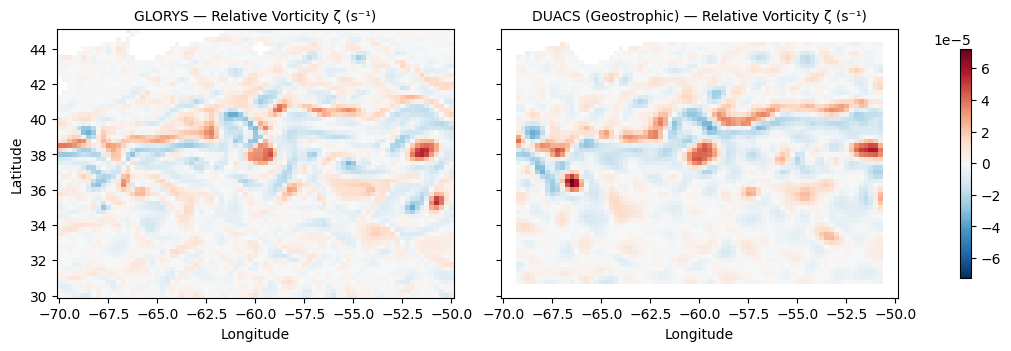

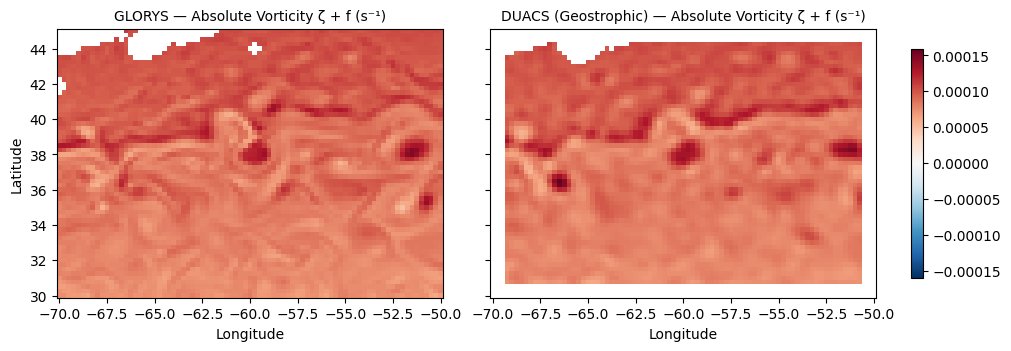

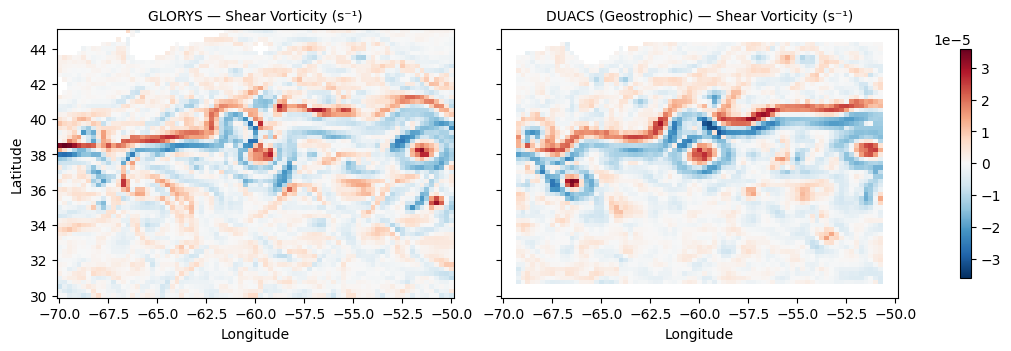

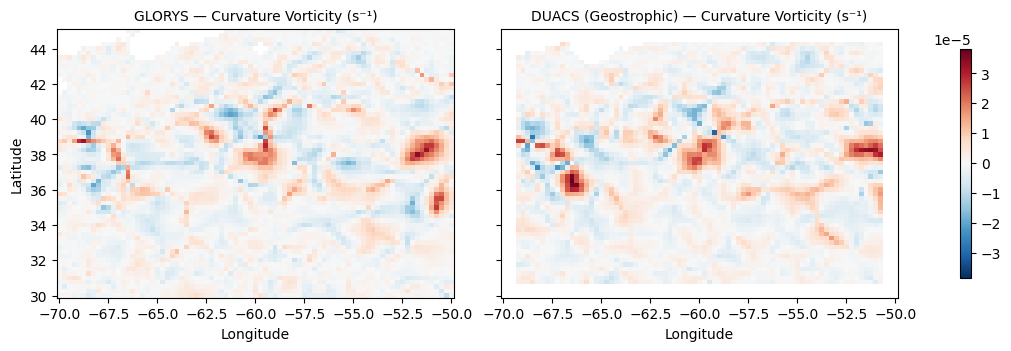

In [9]:
rv_op = RelativeVorticity()
av_op = AbsoluteVorticity()
sv_op = ShearVorticity()
cv_op = CurvatureVorticity()

for op, key, title in [
    (rv_op, "vort_r", "Relative Vorticity ζ (s⁻¹)"),
    (av_op, "vort_a", "Absolute Vorticity ζ + f (s⁻¹)"),
    (sv_op, "vort_shear", "Shear Vorticity (s⁻¹)"),
    (cv_op, "vort_curv", "Curvature Vorticity (s⁻¹)"),
]:
    two_panel(op(glorys_t)[key], op(duacs_t)[key], title)

Implementation:

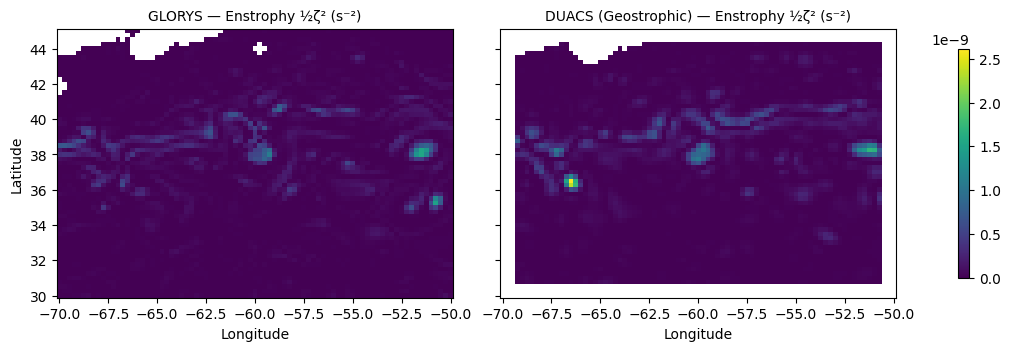

In [10]:
ens_op = Enstrophy(variable="vort_r")
ens_g = ens_op(glorys_t.merge(rv_op(glorys_t), compat="no_conflicts"))["ens"]
ens_d = ens_op(duacs_t.merge(rv_op(duacs_t), compat="no_conflicts"))["ens"]
two_panel(ens_g, ens_d, "Enstrophy ½ζ² (s⁻²)", cmap="viridis", center_zero=False)

## 6 — Strain and deformation

### 6a. Horizontal divergence

**ELI5.** Are fluid parcels spreading apart or piling together?

**What it is.** The horizontal divergence of the velocity. In an incompressible 3-D flow it equals minus the vertical stretching $\partial w / \partial z$, so non-zero horizontal divergence signals vertical motion (upwelling / downwelling). Pure geostrophic flow on the $f$-plane is non-divergent — this metric is the canonical test of "how geostrophic is your velocity field?"

**Continuous formulation.**

$$
    \nabla_h \cdot \mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}.
$$

**Discretisation.** Two spherical-metric central FD calls and a sum.

**Interpretation.** DUACS divergence ≈ 0 by construction (its $u, v$ are geostrophic). GLORYS shows finite, signed divergence with magnitude $10^{-6}$ s⁻¹ — small relative to vorticity, but its spatial pattern marks where the flow has ageostrophic vertical structure (frontal zones, strong eddies). Useful as a sanity check on derived velocity fields and as an input to upwelling diagnostics.

### 6b. Strain components and magnitude

**ELI5.** Take a tiny circular blob of water; the strain is what shape it stretches into. Two ways: shear strain (rectangle distorting to a parallelogram) and tensor (also called "normal" or "stretch") strain (rectangle stretching along one axis and compressing along the other). The magnitude is the total amount of squishing.

**What it is.** The symmetric part of the velocity gradient tensor. The shear and tensor components are standard 2-D decompositions; their root-sum-of-squares is the Frobenius norm of the strain-rate tensor.

**Continuous formulation.**

$$
    S_{\text{shear}} = \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y},
    \qquad
    S_{\text{tensor}} = \frac{\partial u}{\partial x} - \frac{\partial v}{\partial y},
    \qquad
    |S| = \sqrt{S_{\text{shear}}^2 + S_{\text{tensor}}^2}.
$$

**Discretisation.** Same four primitive partials as the vorticity decomposition, recombined with different signs. No additional FD calls beyond what's already cached.

**Interpretation.** Strain $|S|$ is largest in the jet front and the stretching filaments around eddies — the regions where tracers (heat, salt, biology) get drawn out into thin streaks. Comparing $|S|$ to $|\zeta|$ tells you whether a region is **strain-dominated** (filaments, sub-mesoscale) or **rotation-dominated** (eddy cores). The Okubo-Weiss parameter (next) formalises this comparison.

### 6c. Okubo-Weiss

**ELI5.** A single sign-bit per pixel: positive means strain wins (the flow tears tracers apart), negative means rotation wins (the flow spins them around). Used to identify eddy interiors automatically.

**What it is.** The classical Okubo-Weiss criterion. Negative $W$ marks coherent vortex cores; positive $W$ marks strain-dominated regions where tracer gradients sharpen.

**Continuous formulation.**

$$
    W = S_{\text{shear}}^2 + S_{\text{tensor}}^2 - \zeta^2 = |S|^2 - \zeta^2.
$$

**Discretisation.** Reuses the strain and vorticity primitives — no new derivatives.

**Interpretation.** Threshold $W < W_0$ (with $W_0$ usually $-0.2 \times \mathrm{std}(W)$) is the standard automated eddy detector. The Gulf Stream rings shed off the front show up as compact negative blobs in $W$. The diagnostic is qualitative: it doesn't quantify eddy strength, only locates vortex-dominated regions.

### 6d. Frontogenesis

**ELI5.** Take some scalar field (temperature, salinity, SSH). The flow can either sharpen its gradients (frontogenesis, positive) or smear them out (frontolysis, negative). This metric tells you which.

**What it is.** The rate of change of the squared scalar gradient under the action of the flow's deformation tensor. Standard diagnostic for understanding how mesoscale flow organises (or destroys) sub-mesoscale fronts.

**Continuous formulation.** For a scalar $c$ with horizontal gradient $\nabla_h c$:

$$
    \mathcal{F}_c = -\nabla_h c \cdot (\nabla_h \mathbf{u}_h \cdot \nabla_h c)
        = -\left[\frac{\partial u}{\partial x}\,(\partial_x c)^2
                + \left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}\right)
                  \partial_x c\,\partial_y c
                + \frac{\partial v}{\partial y}\,(\partial_y c)^2\right].
$$

Positive $\mathcal{F}$ means the flow is sharpening the gradient of $c$.

**Discretisation.** Six primitive partials (two on $c$, four on velocity), then the algebraic combination above. We pass `scalar="ssh"` to point at SSH, but the same operator works on temperature, salinity, or any other tracer the input Dataset carries.

**Interpretation.** Strong positive frontogenesis along the Gulf Stream front shows the deformation field is actively maintaining the sharp SSH gradient there. The metric is a key input to ocean-front detection pipelines and to understanding sub-mesoscale dynamics; the same diagnostic on temperature or salinity maps where mixed-layer fronts are forming or decaying.

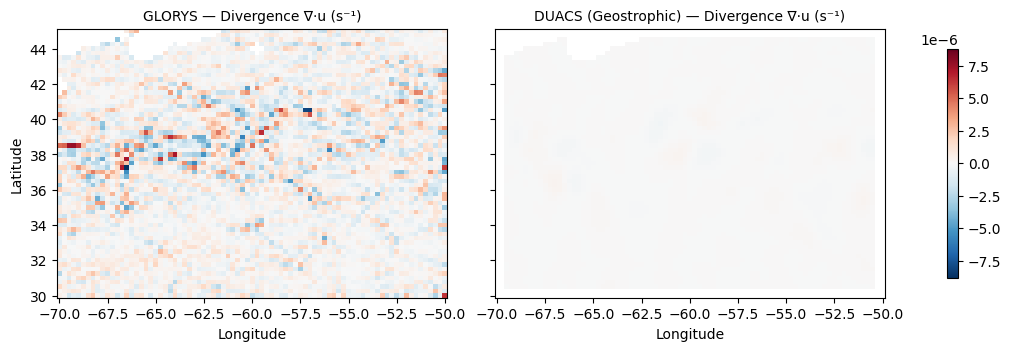

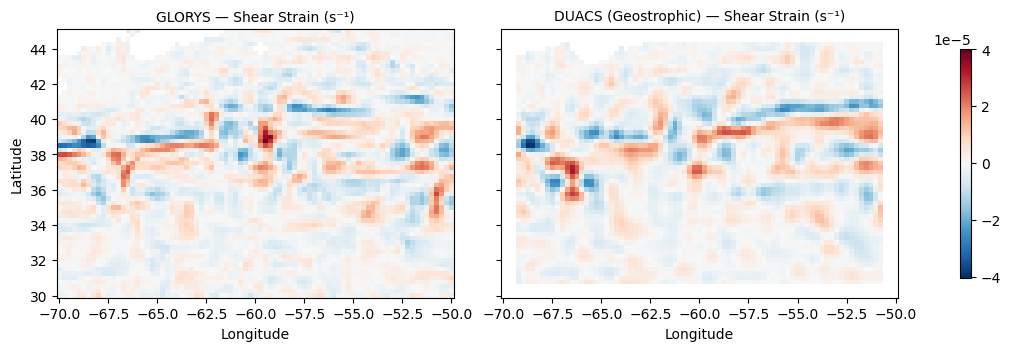

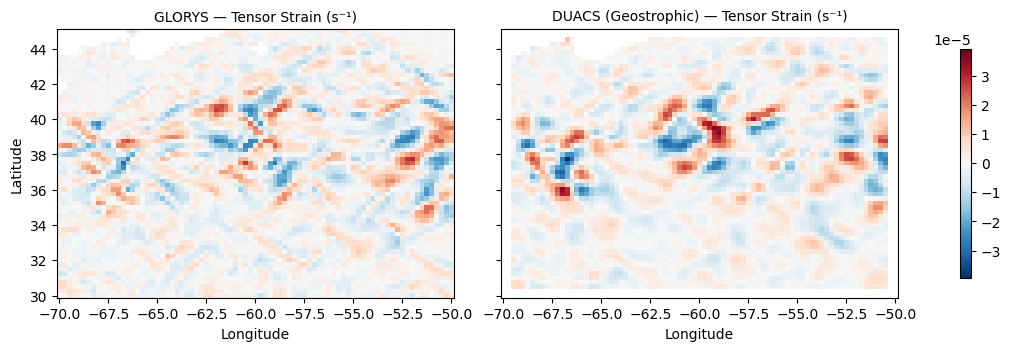

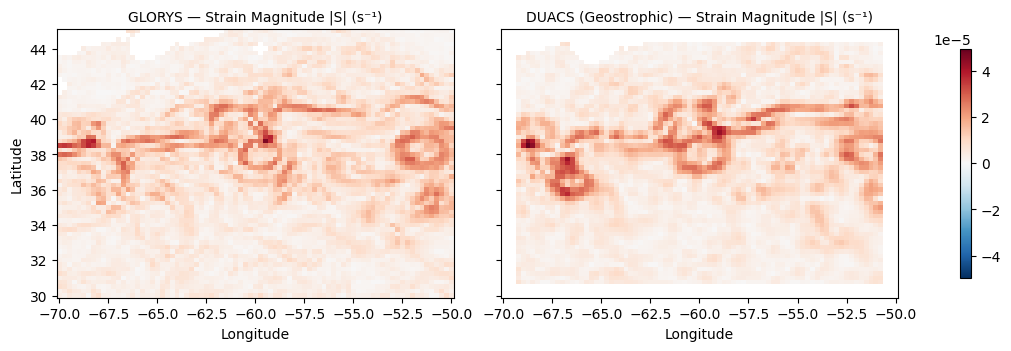

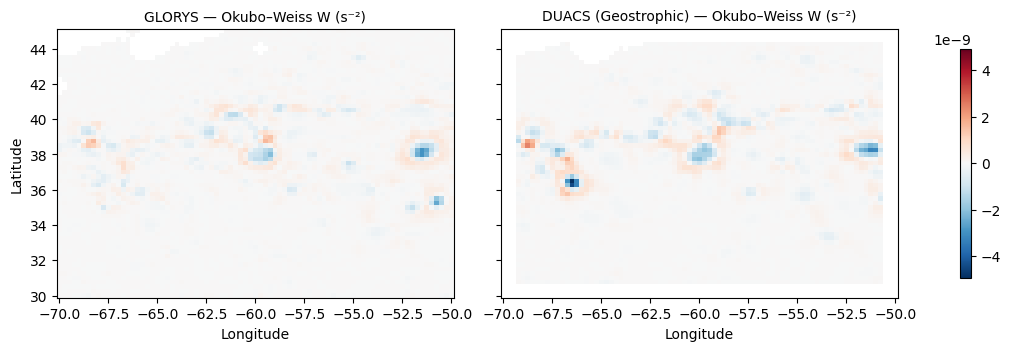

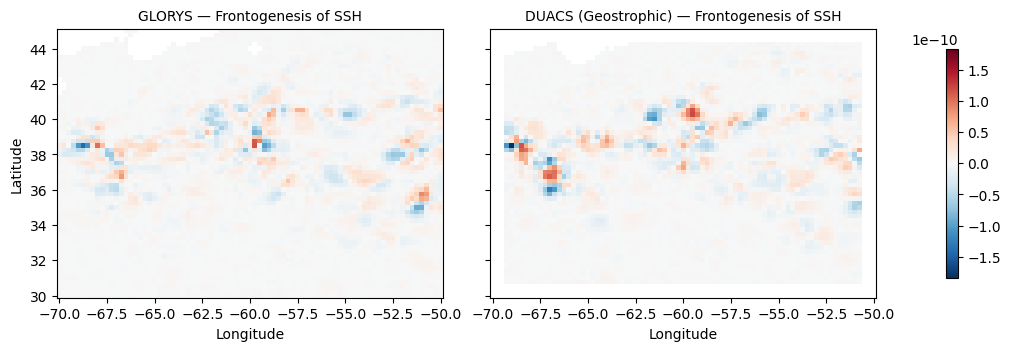

In [11]:
div_op = Divergence()
ss_op = ShearStrain()
ts_op = TensorStrain()
sm_op = StrainMagnitude()
ow_op = OkuboWeiss()
fg_op = Frontogenesis(scalar="ssh")

for op, key, title in [
    (div_op, "div", "Divergence ∇·u (s⁻¹)"),
    (ss_op, "shear_strain", "Shear Strain (s⁻¹)"),
    (ts_op, "tensor_strain", "Tensor Strain (s⁻¹)"),
    (sm_op, "strain", "Strain Magnitude |S| (s⁻¹)"),
    (ow_op, "ow", "Okubo–Weiss W (s⁻²)"),
    (fg_op, "ssh_frontogenesis", "Frontogenesis of SSH"),
]:
    two_panel(op(glorys_t)[key], op(duacs_t)[key], title)

## 7 — Bonus: a `Sequential` "diagnostics pipeline"

Each transformation above is a single-input `Operator` that *replaces* its input — running them in sequence would discard the original dataset. To **augment** a Dataset with derived columns instead, wrap each op in `xr_toolz.Augment`: it runs the inner op and merges its output back into the input, leaving every existing variable in place. Chained via `Sequential`, one call returns a Dataset enriched with every diagnostic.

In [12]:
diagnostics = Sequential(
    [
        Augment(RelativeVorticity()),
        Augment(Divergence()),
        Augment(StrainMagnitude()),
        Augment(OkuboWeiss()),
        Augment(KineticEnergy()),
    ]
)
print(diagnostics.describe())

Sequential (5 ops)
├── Augment(inner={'class': 'RelativeVorticity', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'Divergence', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'StrainMagnitude', 'config': {'u': 'u', 'v': 'v'}})
├── Augment(inner={'class': 'OkuboWeiss', 'config': {'u': 'u', 'v': 'v'}})
└── Augment(inner={'class': 'KineticEnergy', 'config': {'u': 'u', 'v': 'v'}})


In [13]:
glorys_diag = diagnostics(glorys_t)
duacs_diag = diagnostics(duacs_t)
print("GLORYS columns after pipeline:", list(glorys_diag.data_vars))
print("DUACS  columns after pipeline:", list(duacs_diag.data_vars))

GLORYS columns after pipeline: ['ssh', 'u', 'v', 'vort_r', 'div', 'strain', 'ow', 'ke']
DUACS  columns after pipeline: ['ssh', 'u', 'v', 'vort_r', 'div', 'strain', 'ow', 'ke']


## 8 — Bonus: full `Graph` — every headline diagnostic as a terminal node

`Graph` lets a single object carry a DAG with one `Input(name='state')` and a terminal `Node` per diagnostic. One `scorecard(state=ds)` call returns a dict of every diagnostic Dataset — convenient when downstream code needs each diagnostic as its own object (panels, exports) rather than merged columns.

In [14]:
state = Input(name="state")

scorecard = Graph(
    inputs={"state": state},
    outputs={
        "vorticity": RelativeVorticity()(state),
        "divergence": Divergence()(state),
        "strain": StrainMagnitude()(state),
        "okubo_weiss": OkuboWeiss()(state),
        "kinetic_energy": KineticEnergy()(state),
        "ageostrophic": AgeostrophicVelocities(variable="ssh", u="u", v="v")(state),
    },
)
scorecard

Graph(inputs={'state': 0}, outputs={'vorticity': 6, 'divergence': 5, 'strain': 4, 'okubo_weiss': 3, 'kinetic_energy': 2, 'ageostrophic': 1}, steps=[{'index': 0, 'input': 'state'}, {'index': 1, 'class': 'AgeostrophicVelocities', 'config': {'variable': 'ssh', 'u': 'u', 'v': 'v'}, 'parents': [0]}, {'index': 2, 'class': 'KineticEnergy', 'config': {'u': 'u', 'v': 'v'}, 'parents': [0]}, {'index': 3, 'class': 'OkuboWeiss', 'config': {'u': 'u', 'v': 'v'}, 'parents': [0]}, {'index': 4, 'class': 'StrainMagnitude', 'config': {'u': 'u', 'v': 'v'}, 'parents': [0]}, {'index': 5, 'class': 'Divergence', 'config': {'u': 'u', 'v': 'v'}, 'parents': [0]}, {'index': 6, 'class': 'RelativeVorticity', 'config': {'u': 'u', 'v': 'v'}, 'parents': [0]}])

In [15]:
out_glorys = scorecard(state=glorys_t)
out_duacs = scorecard(state=duacs_t)

# Quick scalar summary: basin-mean magnitude of each diagnostic.
import pandas as pd

def basin_mean(ds, key):
    arr = ds[key] if isinstance(ds, xr.Dataset) else ds
    return float(np.abs(arr).mean(skipna=True).values)


summary = pd.DataFrame(
    {
        "GLORYS": {
            "|ζ|": basin_mean(out_glorys["vorticity"], "vort_r"),
            "|div|": basin_mean(out_glorys["divergence"], "div"),
            "|strain|": basin_mean(out_glorys["strain"], "strain"),
            "|W|": basin_mean(out_glorys["okubo_weiss"], "ow"),
            "KE": basin_mean(out_glorys["kinetic_energy"], "ke"),
            "|u_ageo|": float(
                np.hypot(out_glorys["ageostrophic"]["u_a"], out_glorys["ageostrophic"]["v_a"])
                .mean(skipna=True)
                .values
            ),
        },
        "DUACS (geostrophic)": {
            "|ζ|": basin_mean(out_duacs["vorticity"], "vort_r"),
            "|div|": basin_mean(out_duacs["divergence"], "div"),
            "|strain|": basin_mean(out_duacs["strain"], "strain"),
            "|W|": basin_mean(out_duacs["okubo_weiss"], "ow"),
            "KE": basin_mean(out_duacs["kinetic_energy"], "ke"),
            "|u_ageo|": float(
                np.hypot(out_duacs["ageostrophic"]["u_a"], out_duacs["ageostrophic"]["v_a"])
                .mean(skipna=True)
                .values
            ),
        },
    }
)
summary

,GLORYS,DUACS (geostrophic)
|ζ|,6.060888e-06,6.572022e-06
|div|,9.155689e-07,3.384506e-08
|strain|,6.907644e-06,7.399212e-06
|W|,8.085962e-11,1.115302e-10
KE,7.568002e-02,9.615022e-02
|u_ageo|,6.113717e-02,1.952778e-16


## 9 — Takeaway

Every kinematic diagnostic in `xr_toolz.ocn` is a single-input `Operator` over an xarray Dataset, with a stable `(u, v)` / `(ssh)` contract on the input variables. Because the contract is uniform, the same diagnostic suite drops onto any product — full prognostic state (GLORYS) or SSH-only altimetry (DUACS, after `geostrophic_velocities`). The two-panel figures show where the products agree (large-scale Gulf Stream vorticity and KE) and where they do not (`|u_ageo|` is non-zero for GLORYS by definition; sub-mesoscale strain is sharper in GLORYS at this 0.25° regrid). With `Sequential` the diagnostics merge back into the dataset in one call, and with `Graph` they become independently-addressable nodes for downstream pipelines.

**Companion notebooks** in this PR cover the diagnostics this one omits:
- SSH along-track / unfiltered transformations.
- Stratification (density, mixed-layer depth, Brunt-Väisälä, advection, barotropic PV).